# 01 — Measurement setup, fairness and validity

**Objective.** Establish that vLLM and llama.cpp were measured under the same controlled conditions, and that
the instruments (load client, telemetry, nodes) are accurate enough for the comparisons in notebooks 02–09.

**Research question.** Is the backend comparison fair, and can its measurements be trusted?

**Data.** `data/processed/` tables built from the campaigns `online/main` (primary measurements),
`stream/calibration` (sustainable bandwidth), `online/pmu-overhead` (instrument overhead) and `online/tuning`
(backend tuning). Campaign roles are declared in `data/metadata/campaigns.toml`.

**Method.** Validity statistics are computed over every repetition of the primary campaign. The memory-traffic
instrument (per-thread core offcore-response counters) is calibrated against STREAM triad, whose traffic is
known by construction, and its overhead is measured with an A/B/A/B test.

**Assumptions.** Nodes of the `cresco8_hbm` partition are nominally identical; the per-job STREAM node check
is used to verify that assumption rather than to take it for granted.

In [1]:
import pandas as pd
from IPython.display import display

from llm_backend_analysis.analysis import comparisons, memory, metrics
from llm_backend_analysis.data import loaders, registry
from llm_backend_analysis.reporting import Claim, claims_table, num, pct, rng, show, table, x
from llm_backend_analysis.visualization import plots, theme
from llm_backend_analysis.visualization.export import export_figure

theme.setup_notebook()
NOTEBOOK = "01_measurement_validity.ipynb"
MODEL = registry.primary_model()  # Llama-3.1-8B-Instruct; the 1B model is the cross-check
from llm_backend_analysis.analysis import tuning

## 1. What was compared

One *configuration* is a backend with one weight representation. The harness calls it an *arm*; the canonical
identifiers (`configuration_id`, `backend`, `precision`, `quantization`) come from
`data/metadata/configurations.toml`. `vllm_int8` is prepared (checkpoint built and quality-checked) but not yet
measured.

In [2]:
conf = registry.configurations_frame()
display(table(conf[["configuration_id", "label", "weight_format", "kv_cache_dtype", "amx_path", "status"]]
              .rename(columns={"configuration_id": "Configuration", "label": "Label", "weight_format": "Weights",
                               "kv_cache_dtype": "KV cache", "amx_path": "AMX path", "status": "Status"})))

Configuration,Label,Weights,KV cache,AMX path,Status
vllm_bf16,vLLM · BF16,safetensors (HF snapshot),bf16,BF16 tiles for weight GEMMs and attention,measured
llama_cpp_bf16,llama.cpp · BF16,GGUF BF16 (lossless conversion of the same snapshot),f16,none: llama.cpp has no BF16 AMX kernel (AVX-512-BF16 instead),measured
llama_cpp_int8,llama.cpp · INT8 (Q8_0),"GGUF Q8_0 (RTN, one scale per 32 weights, from the BF16 GGUF)",f16,INT8 tiles for weight GEMMs with >= 2 rows; AVX-512 VNNI at 1 row,measured
vllm_int8,vLLM · INT8 (W8A8),"compressed-tensors W8A8 (RTN, per-channel weights, dynamic per-token activations)",bf16,INT8 tiles via vLLM's CPU int8_scaled_mm kernel,pending


In [3]:
topo = registry.topology()
display(table(pd.DataFrame([
    ("Memory mode", f"HBM {topo['memory_mode']} mode (64 GiB HBM2e per socket in front of DDR5)"),
    ("Server compute threads", f"{topo['compute_threads']} OpenMP threads on cores {topo['compute_cpus']}"),
    ("Server process tree", f"cores {topo['server_cpus']}, numactl --membind={topo['server_mem_node']}"),
    ("HTTP front end", f"core {topo['frontend_cpu']}"),
    ("Client, telemetry, orchestrator", f"cores {topo['client_cpus']} (socket 1), memory node {topo['client_mem_node']}"),
], columns=["Item", "Setting"])))
wl = registry.workloads()
display(table(wl[["workload", "workload_label", "isl", "osl"]].rename(columns={
    "workload": "Workload", "workload_label": "Description", "isl": "Input tokens", "osl": "Output tokens"})))
md = registry.models()
display(table(md[["model", "hf_id", "revision", "params", "kv_bytes_per_token", "primary"]]
              .assign(revision=md["revision"].str[:7], params=md["params"] / 1e9)
              .rename(columns={"params": "Parameters (B)", "kv_bytes_per_token": "KV bytes / token"}),
              {"Parameters (B)": "{:.2f}"}))

Item,Setting
Memory mode,HBM cache mode (64 GiB HBM2e per socket in front of DDR5)
Server compute threads,55 OpenMP threads on cores 0-54
Server process tree,"cores 0-55, numactl --membind=0"
HTTP front end,core 55
"Client, telemetry, orchestrator","cores 100-111 (socket 1), memory node 1"


Workload,Description,Input tokens,Output tokens
decode,Decode-heavy 128→512,128,512
balanced,Balanced 512→512,512,512
prefill,Prefill-heavy 4096→128,4096,128
longctx,Long context 8192→256,8192,256
kvdecode,Long-KV decode 4096→1024,4096,1024


model,hf_id,revision,Parameters (B),KV bytes / token,primary
llama31_8b,meta-llama/Llama-3.1-8B-Instruct,0e9e39f,8.03,131072,True
llama32_1b,meta-llama/Llama-3.2-1B-Instruct,9213176,1.24,32768,False


## 2. Fair-comparison controls

The comparison is server against server (`vllm serve` vs `llama-server`) through **one shared client**
(`scripts/benchmark/bench_client.py`). Controls that are identical for both backends:

| Control | Setting |
| --- | --- |
| Weights | Same Hugging Face snapshot and revision. llama.cpp BF16 is a lossless GGUF conversion of it |
| Prompts | Token-id lists (BOS + ISL−1 deterministic pseudo-random tokens): no tokenizer or chat-template difference, no shared prefixes |
| Output length | `max_tokens = OSL`, `ignore_eos`, temperature 0; every request's token counts are checked |
| Prompt / prefix caching | Off in both servers |
| KV sizing | Each server sized for exactly C full-length sequences |
| Server state | Fresh server per concurrency point; idle baseline, warm-up, then 3 measured repetitions |
| Load | Closed loop with C workers; throughput in the steady window in which exactly C requests are in flight |
| Placement | Same cores (0–54 compute, 55 front end) and memory node 0; client on the other socket |
| Sweep rule | Declared before measuring: C = 1…64, stop after two doublings < +5%, extend to 128/256 while the last doubling gained ≥ 10%, skip points projected > 4 h |

Differences that remain and are reported rather than hidden:

1. **Weight file format** (safetensors vs GGUF); the BF16 values are identical.
2. **KV-cache type**: vLLM BF16, llama.cpp F16 — both 2 bytes per element. llama.cpp with a BF16 KV cache was
   slower in tuning (section 6), so F16 was kept.
3. **Thread binding**: vLLM binds its OpenMP threads itself, llama.cpp through `OMP_PROC_BIND=close`; both end
   on cores 0–54.
4. **Process structure**: vLLM runs its HTTP front end as a separate process, llama.cpp in the same process.
5. **AMX coverage differs by design**: llama.cpp has no BF16 AMX kernel, so the BF16 pair compares vLLM *with*
   AMX against llama.cpp *without* it. This is a property of the engines at matched precision, not a setup
   error; the INT8 pair (both engines on AMX-INT8) is the controlled check and is pending for vLLM.
6. **INT8 quantization methods** differ in scale granularity (vLLM W8A8: per-channel weights, per-token
   activations; llama.cpp Q8_0: one scale per 32 weights).

## 3. Run validity

Every repetition of the primary campaign is checked for failed requests, exact token counts, identical prompt
manifests across repetitions, client load, and an idle compute-core baseline before each point.

In [4]:
reps = loaders.online_repetitions()
pts = loaders.online_points()
jobs = loaders.node_checks().assign(slurm_job_id=lambda d: d["slurm_job_id"].astype(str))
campaign_jobs = jobs[jobs["slurm_job_id"].isin(reps["slurm_job_id"].astype(str))]
validity = pd.DataFrame([
    ("Concurrency points (all configurations, both models)", num(len(pts))),
    ("Measured repetitions", num(len(reps))),
    ("Measured requests", num(reps["requests"].sum())),
    ("Failed requests", num(reps["failed"].sum())),
    ("Prompt and completion token counts exact", "all requests" if (reps["prompt_tokens_ok"] & reps["completion_tokens_ok"]).all() else "NO"),
    ("Prompt manifest identical across repetitions", "all points" if pts["manifest_consistent"].all() else "NO"),
    ("Throughput coefficient of variation (median / max)", f"{pct(pts['total_tok_s_cv'].median(), 2, False)} / {pct(pts['total_tok_s_cv'].max(), 1, False)}"),
    ("Client CPU, max fraction of one core", f"{reps['client_cpu_frac'].max():.2f}"),
    ("Client event-loop lag, max", f"{reps['client_loop_lag_max_ms'].max():.0f} ms"),
    ("Compute-core busy during idle baselines, max", pct(reps["idle_cpu_busy_compute"].max(), 1, False)),
    ("Node check (STREAM 8 GiB, 55 threads) on campaign jobs", f"{rng(campaign_jobs['triad_gbs'])} GB/s on {campaign_jobs['host'].nunique()} nodes"),
], columns=["Check", "Result"])
display(table(validity))
worst = pts.loc[pts["total_tok_s_cv"].idxmax()]
show(f"Least repeatable point: {worst['model']} {worst['configuration_label']} {worst['workload_shape']} at C={worst['concurrency']} "
     f"(CV {pct(worst['total_tok_s_cv'], 1, False)}).")

Check,Result
"Concurrency points (all configurations, both models)",145
Measured repetitions,435
Measured requests,"28,932"
Failed requests,0
Prompt and completion token counts exact,all requests
Prompt manifest identical across repetitions,all points
Throughput coefficient of variation (median / max),0.17% / 6.0%
"Client CPU, max fraction of one core",0.30
"Client event-loop lag, max",62 ms
"Compute-core busy during idle baselines, max",1.8%


Least repeatable point: llama32_1b vLLM · BF16 512→512 at C=32 (CV 6.0%).

**Interpretation.** No request failed, every request received exactly the requested number of prompt and
completion tokens, and repetitions agree to well under 1 % for almost every point, so differences of a few
percent between configurations are resolvable. The client stays far from saturating its own core, and the
compute cores are idle before each point starts, so neither the load generator nor a stray process shapes the
results. The per-job node check confirms that all campaign jobs ran on nodes with the expected cache-mode
bandwidth (jobs below 450 GB/s abort automatically; one node with an orphaned process was caught this way during
the smoke phase).

## 4. Sustainable bandwidth and the memory-traffic instrument (Experiment 0)

Uncore counters (DDR, HBM, near-memory-cache tags) are not readable on CRESCO8 (`perf_event_paranoid=2`), so
memory traffic is measured from the cores: offcore-response L3-miss reads and the write estimate, per server
thread. STREAM triad runs under the same sampler on the server's cores at working sets of 4–96 GiB, which gives
(i) the sustainable bandwidth of the layout and (ii) a check of the instrument against traffic that is known by
construction.

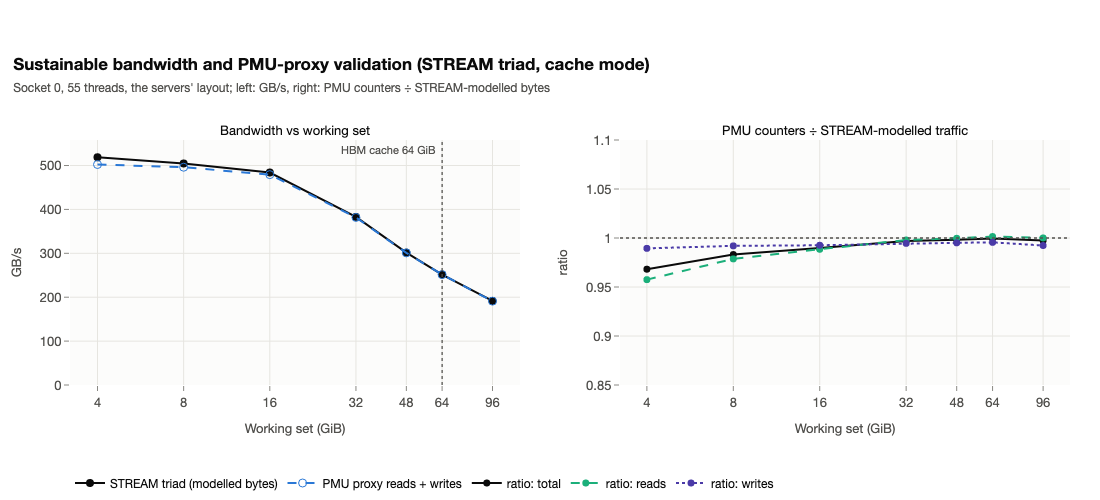

In [5]:
stream = loaders.stream_calibration()
threads = registry.topology()["compute_threads"]
fig = plots.stream_calibration_figure(
    stream, threads, title="Sustainable bandwidth and PMU-proxy validation (STREAM triad, cache mode)",
    subtitle=f"Socket 0, {threads} threads, the servers' layout; left: GB/s, right: PMU counters ÷ STREAM-modelled bytes")
fig.show()
export_figure(fig, "stream_calibration", source=NOTEBOOK,
              caption="STREAM triad bandwidth vs working set on the server layout, and the PMU proxy's capture ratio.")

In [6]:
s = stream[stream["threads"] == threads].set_index("working_set_gib")
small = s[s.index <= 8]
show(f"Sustainable triad bandwidth: {rng(small['stream_triad_gbs'])} GB/s up to 8 GiB, then "
     + ", ".join(f"{num(s.loc[w, 'stream_triad_gbs'])} GB/s at {w:g} GiB" for w in s.index if w > 8)
     + f". PMU reads + writes ÷ modelled traffic: {rng(s['pmu_total_over_stream'], num, nd=2)}; reads alone "
     f"{rng(s['pmu_read_over_stream_read'], num, nd=2)}, writes {rng(s['pmu_write_over_stream_write'], num, nd=2)}.")

Sustainable triad bandwidth: 505–519 GB/s up to 8 GiB, then 484 GB/s at 16 GiB, 383 GB/s at 32 GiB, 302 GB/s at 48 GiB, 252 GB/s at 64 GiB, 191 GB/s at 96 GiB. PMU reads + writes ÷ modelled traffic: 0.97–1.00; reads alone 0.96–1.00, writes 0.99–1.00.

**Interpretation.** The core-side counters reproduce STREAM's modelled traffic within a few percent at every
working set, for reads and writes separately, without multiplexing. Server traffic measured with the same
instrument can therefore be normalized by the *measured* sustainable bandwidth (≈ 500 GB/s with the 55-thread
layout) instead of a theoretical HBM peak. Beyond 16 GiB the sustainable bandwidth falls as the working set
competes for the 64 GiB direct-mapped HBM cache; every server working set in this study is below 47 GiB.

*Processing correction (2026-10-04).* Triad reads two arrays and writes one, so reads are 2/3 of the modelled
bytes. The earlier processing divided reads by the full modelled traffic and showed a misleading read ratio of
≈ 0.65; the raw data are unchanged and the correction lives in
`src/llm_backend_analysis/data/processing/stream.py`.

**Limit of the instrument.** In cache mode the counters see HBM-cache hits and DDR traffic *together*; they
cannot split them, and they do not see the cache's own fills and evictions.

## 5. Does the telemetry slow the servers down?

Same node, same point (1B, balanced, C=1), telemetry with and without core counters in A/B/A/B order.

In [7]:
rows = []
for campaign in ("pmu-overhead", "pmu-overhead-v1-7events"):
    d = loaders.pmu_overhead(campaign)
    g = d.groupby(["configuration_id", "pmu_enabled"])["tpot_s_p50"].mean().unstack()
    for cid, r in g.iterrows():
        rows.append({"Event set": "final (5 events)" if campaign == "pmu-overhead" else "first (7 events, superseded)",
                     "Configuration": registry.configuration_label(cid),
                     "TPOT without PMU (ms)": r[False] * 1e3, "TPOT with PMU (ms)": r[True] * 1e3,
                     "Overhead": r[True] / r[False] - 1})
overhead = pd.DataFrame(rows)
display(table(overhead, {"TPOT without PMU (ms)": "{:.2f}", "TPOT with PMU (ms)": "{:.2f}", "Overhead": "{:+.1%}"}))
final = overhead[overhead["Event set"].str.startswith("final")]
show(f"Final event set: TPOT change with counters on = {rng(final['Overhead'], pct, nd=1)} "
     "(single A/B/A/B pairs; run-to-run noise at this point is about ±1%).")

Event set,Configuration,TPOT without PMU (ms),TPOT with PMU (ms),Overhead
final (5 events),llama.cpp · BF16,9.29,9.22,-0.7%
final (5 events),vLLM · BF16,11.88,11.99,+0.9%
"first (7 events, superseded)",llama.cpp · BF16,9.20,9.33,+1.4%
"first (7 events, superseded)",vLLM · BF16,11.83,12.36,+4.5%


Final event set: TPOT change with counters on = -0.7%–+0.9% (single A/B/A/B pairs; run-to-run noise at this point is about ±1%).

**Interpretation.** The first event set multiplexed two counters and slowed vLLM's decode measurably; it was
replaced before the campaign. The final set's effect is within run-to-run noise for both servers, so telemetry
does not bias the comparison.

## 6. Backend tuning

Each backend was given a small, documented tuning grid on the 8B balanced workload (C=1 and C=16, one
repetition), so neither runs on an inappropriate default. The selection rule was declared before tuning:
highest steady throughput at C=16, unless median TPOT at C=1 worsens by more than 5% over the default.

In [8]:
tune = loaders.tuning_runs()
grid = tune.pivot_table(index=["configuration_label", "variant"], columns="concurrency",
                        values=["total_tok_s", "tpot_s_p50"]).reset_index()
grid.columns = ["Configuration", "Variant", "Total tok/s, C=1", "Total tok/s, C=16", "TPOT C=1 (ms)", "TPOT C=16 (ms)"]
grid[["TPOT C=1 (ms)", "TPOT C=16 (ms)"]] *= 1e3
display(table(grid, {c: "{:.1f}" for c in grid.columns[2:]}))
choice = tuning.select_variants(tune)
display(table(choice.assign(configuration_id=choice["configuration_id"].map(registry.configuration_label))
              [["configuration_id", "default_variant", "chosen_variant", "gain_over_default", "reason"]]
              .rename(columns={"configuration_id": "Configuration", "default_variant": "Default",
                               "chosen_variant": "Chosen", "gain_over_default": "C=16 gain vs default",
                               "reason": "Reason"}), {"C=16 gain vs default": "{:+.1%}"}))

Configuration,Variant,"Total tok/s, C=1","Total tok/s, C=16",TPOT C=1 (ms),TPOT C=16 (ms)
llama.cpp · BF16,fa-off_ub2048,35.6,124.3,51.4,250.2
llama.cpp · BF16,fa-off_ub512,35.1,122.4,52.3,247.2
llama.cpp · BF16,fa-on_ub2048,38.1,141.6,48.1,219.4
llama.cpp · BF16,fa-on_ub512,38.5,142.8,47.6,218.0
llama.cpp · BF16,fa-on_ub512_kvbf16,30.8,115.7,52.6,257.1
llama.cpp · INT8 (Q8_0),fa-off_ub2048,52.6,183.4,34.8,169.0
llama.cpp · INT8 (Q8_0),fa-off_ub512,52.7,184.1,34.6,168.3
llama.cpp · INT8 (Q8_0),fa-on_ub2048,60.2,231.2,30.2,136.0
llama.cpp · INT8 (Q8_0),fa-on_ub512,59.5,225.9,30.7,137.1
llama.cpp · INT8 (Q8_0),fa-on_ub512_kvbf16,54.5,187.0,33.6,164.4


Configuration,Default,Chosen,C=16 gain vs default,Reason
vLLM · BF16,mnbt4096,mnbt8192,+0.6%,highest C=16 throughput
llama.cpp · BF16,fa-on_ub512,fa-on_ub512,+0.0%,highest C=16 throughput
llama.cpp · INT8 (Q8_0),fa-on_ub512,fa-on_ub2048,+2.3%,highest C=16 throughput


In [9]:
t16 = tune[tune["concurrency"] == 16].set_index(["configuration_id", "variant"])["total_tok_s"]
fa = {cid: t16[(cid, "fa-on_ub512")] / t16[(cid, "fa-off_ub512")] - 1 for cid in ("llama_cpp_bf16", "llama_cpp_int8")}
kv = {cid: t16[(cid, "fa-on_ub512_kvbf16")] / t16[(cid, "fa-on_ub512")] - 1 for cid in ("llama_cpp_bf16", "llama_cpp_int8")}
vllm = tune[(tune["configuration_id"] == "vllm_bf16") & (tune["concurrency"] == 16)]["total_tok_s"]
show(f"llama.cpp flash attention on vs off at C=16: {', '.join(f'{registry.configuration_label(k)} {pct(v)}' for k, v in fa.items())}. "
     f"BF16 instead of F16 KV cache: {', '.join(f'{registry.configuration_label(k)} {pct(v)}' for k, v in kv.items())}. "
     f"vLLM `max_num_batched_tokens` 2048/4096/8192: spread {pct(vllm.max() / vllm.min() - 1, 1, False)}.")

llama.cpp flash attention on vs off at C=16: llama.cpp · BF16 +17%, llama.cpp · INT8 (Q8_0) +23%. BF16 instead of F16 KV cache: llama.cpp · BF16 -19%, llama.cpp · INT8 (Q8_0) -17%. vLLM `max_num_batched_tokens` 2048/4096/8192: spread 0.7%.

**Interpretation.** Flash attention is the only setting with a large effect (llama.cpp); the chosen settings
are those copied into `configs/experiment.toml` `[tuned.*]`. vLLM is insensitive to its batching knob in this
range. Differences below ~2.5% are within single-repetition noise; the rule was applied as declared anyway.

## Conclusions

- The two backends were measured under identical requests, placement, client and sweep rules; the remaining
  differences are listed in section 2 and none of them favours one backend's throughput by construction.
- Measurements are repeatable (median CV well below 1%), complete (no failed requests) and exact in token
  counts.
- The memory-traffic instrument is validated against STREAM and does not perturb the servers.

## Limitations

- Memory traffic is HBM-cache + DDR combined; an HBM/DDR split needs uncore access (an administrator would
  have to lower `perf_event_paranoid` on one node).
- Tuning used one repetition per setting and one workload; it guards against bad defaults, not against every
  possible optimization.
- The quality check of the INT8 checkpoints (notebook 08) ran on a non-HBM node (Xeon Platinum 8592+).